# MOONPIERCER — Full Chord PBH Lunar Crater Search Analysis

This notebook is the single comprehensive analysis workspace for the MOONPIERCER pipeline.
It loads HPC results, generates all figures (saved to `plots/pdf/` and `plots/png/`),
and performs statistical analysis.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure moonpiercer is importable
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from moonpiercer.config import ChordConfig
from moonpiercer.constants import LUNAR_RADIUS_M, LUNAR_SURFACE_AREA_KM2
from moonpiercer.geometry import (
    chord_length_from_separation,
    expected_ellipticity_from_separation,
)
from moonpiercer.velocity import (
    max_physical_angular_offset_deg,
    maxwell_boltzmann_speed_pdf,
    rotation_offset_deg,
)
from moonpiercer.null_model import benjamini_hochberg
from moonpiercer.plotting import (
    plot_annotated_chip,
    plot_chord_map,
    plot_crater_map_with_pairs,
    plot_null_distribution,
    plot_pair_scores_with_threshold,
    plot_score_component_star,
    plot_score_distribution,
    plot_spatial_coverage,
    plot_transit_cone_diagram,
)
from moonpiercer.io_utils import (
    PLOTS_PDF_DIR,
    PLOTS_PNG_DIR,
    RESULTS_DIR,
    load_dataframe,
    load_json,
    save_figure,
)

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Read results: {RESULTS_DIR}")
print(f"Plots PDF: {PLOTS_PDF_DIR}")
print(f"Plots PNG: {PLOTS_PNG_DIR}")

Project root: /mnt/beegfs/diogocapelo/moonpiercer
Read results: /mnt/beegfs/diogocapelo/moonpiercer/results
Plots PDF: /mnt/beegfs/diogocapelo/moonpiercer/plots/pdf
Plots PNG: /mnt/beegfs/diogocapelo/moonpiercer/plots/png


## 1. Load HPC Results

In [10]:
# Update these paths to match your HPC run output.
# - mp_run.sbatch writes to results/moonpiercer_full_run by default.
# - mp_resume.sbatch expects the same results directory you pass in.
# Set RUN_NAME or RUN_PATH to force a specific run; otherwise we auto-detect.
RUN_NAME = "moonpiercer_full_run"  # e.g., "moonpiercer_full_run" or "moonpiercer_run"
RUN_PATH = RESULTS_DIR / "moonpiercer_full_run"  # e.g., RESULTS_DIR / "moonpiercer_full_run"


def _select_run_root(results_dir, run_name=None, run_path=None):
    if run_path is not None:
        return Path(run_path).expanduser().resolve()
    if run_name:
        return (results_dir / run_name).resolve()
    if not results_dir.exists():
        return results_dir / "moonpiercer_full_run"

    candidates = []
    for path in results_dir.iterdir():
        if not path.is_dir():
            continue
        if path.name in {"slurm_logs"}:
            continue
        if (path / "global").exists() or (path / "chips").exists() or (path / "manifest.csv").exists():
            candidates.append(path)

    if not candidates:
        return results_dir / "moonpiercer_full_run"

    def _score(p):
        global_dir = p / "global"
        score = 0
        for fname in ("global_summary.json", "all_pairs_scored.csv", "significant_pairs.csv"):
            if (global_dir / fname).exists():
                score += 1
        if (p / "manifest.csv").exists():
            score += 1
        if (global_dir / "global_summary.json").exists():
            ts = (global_dir / "global_summary.json").stat().st_mtime
        else:
            ts = p.stat().st_mtime
        return (score, ts)

    candidates.sort(key=_score, reverse=True)
    return candidates[0]


RUN_ROOT = _select_run_root(RESULTS_DIR, run_name=RUN_NAME, run_path=RUN_PATH)
RUN_DIR = RUN_ROOT / "global"
CHIP_DIR = RUN_ROOT / "chips"

print(f"Selected run directory: {RUN_ROOT}")

# --- Load chip-level results (independent of global pairing) ---
HAS_CHIPS = False
craters = pd.DataFrame()
chip_metadata = []

crater_files = sorted(CHIP_DIR.glob("chip_*/craters.csv"))
if crater_files:
    frames = []
    for f in crater_files:
        df = load_dataframe(f)
        if not df.empty:
            frames.append(df)
    if frames:
        craters = pd.concat(frames, ignore_index=True)
        HAS_CHIPS = True
        print(f"Loaded {len(crater_files)} chip files -> {len(craters):,} craters")
    else:
        print(f"Found {len(crater_files)} chip files, but all are empty.")

# Chip health report
meta_files = sorted(CHIP_DIR.glob("chip_*/metadata.json"))
if meta_files:
    status_counts = {}
    n_craters_total = 0
    for mf in meta_files:
        try:
            m = load_json(mf)
            s = m.get("status", "unknown")
            status_counts[s] = status_counts.get(s, 0) + 1
            n_craters_total += m.get("n_craters", 0)
        except Exception:
            status_counts["read_error"] = status_counts.get("read_error", 0) + 1
    print(f"\nChip health ({len(meta_files)} chips with metadata):")
    for s, n in sorted(status_counts.items(), key=lambda x: -x[1]):
        print(f"  {s:20s}: {n}")
    print(f"  Total craters (metadata): {n_craters_total:,}")

# --- Load global aggregation results ---
HAS_RESULTS = False
summary = {}
all_pairs = pd.DataFrame()
sig_pairs = pd.DataFrame()
null_scores = np.array([])

summary_path = RUN_DIR / "global_summary.json"
all_pairs_path = RUN_DIR / "all_pairs_scored.csv"
sig_pairs_path = RUN_DIR / "significant_pairs.csv"
null_path = RUN_DIR / "null_best_scores.npy"

if summary_path.exists():
    try:
        summary = load_json(summary_path)
    except Exception as e:
        print(f"WARNING: could not read global_summary.json: {e}")

all_pairs = load_dataframe(all_pairs_path)
sig_pairs = load_dataframe(sig_pairs_path)
if null_path.exists():
    null_scores = np.load(null_path)

if summary or not all_pairs.empty:
    HAS_RESULTS = True
    print(f"\nLoaded global results from {RUN_DIR}")
    print(f"  Chips with data: {summary.get('n_chips_with_data', '?')}")
    print(f"  Craters: {summary.get('n_craters', '?')}")
    print(f"  Raw pairs: {summary.get('n_raw_pairs', '?')}")
    print(f"  Significant: {summary.get('n_significant', '?')}")
    if not all_pairs.empty:
        print(f"  Scored pairs loaded: {len(all_pairs):,}")
    else:
        print("  No candidate pairs (all_pairs_scored.csv is empty).")
    if null_scores.size > 0:
        print(f"  Null trials: {null_scores.size:,}")
    else:
        print("  No null model scores found.")
else:
    # Diagnose what's missing
    missing = []
    if not summary_path.exists():
        missing.append("global_summary.json")
    if not all_pairs_path.exists():
        missing.append("all_pairs_scored.csv")
    if missing:
        print(f"\nNo global results found (missing: {', '.join(missing)}).")
    else:
        print("\nGlobal results files exist but contain no data (0 pairs found).")
    print("Pair analysis will be skipped.")

    # Check for partial progress
    checkpoint_dir = RUN_DIR / "checkpoints"
    if checkpoint_dir.exists():
        ckpt_files = list(checkpoint_dir.glob("null_scores_part_*.npy"))
        meta = checkpoint_dir / "checkpoint_meta.json"
        if ckpt_files or meta.exists():
            print(f"  (Found {len(ckpt_files)} null checkpoint chunks — run may be incomplete)")

if not HAS_CHIPS and not HAS_RESULTS:
    print("\nNo HPC results at all. Running in demo mode (methodology figures only).")

Selected run directory: /mnt/beegfs/diogocapelo/moonpiercer/results/moonpiercer_full_run
Loaded 15000 chip files -> 435,705 craters

Chip health (15000 chips with metadata):
  ok                  : 8714
  blank_chip          : 6273
  noise_floor         : 12
  no_data             : 1
  Total craters (metadata): 435,705

Loaded global results from /mnt/beegfs/diogocapelo/moonpiercer/results/moonpiercer_full_run/global
  Chips with data: 8519
  Craters: 435705
  Raw pairs: 115210333
  Significant: 0
  Scored pairs loaded: 50
  Null trials: 2,000


## 2. Methodology Figures

These figures illustrate the pipeline methodology and can be generated
without HPC results.

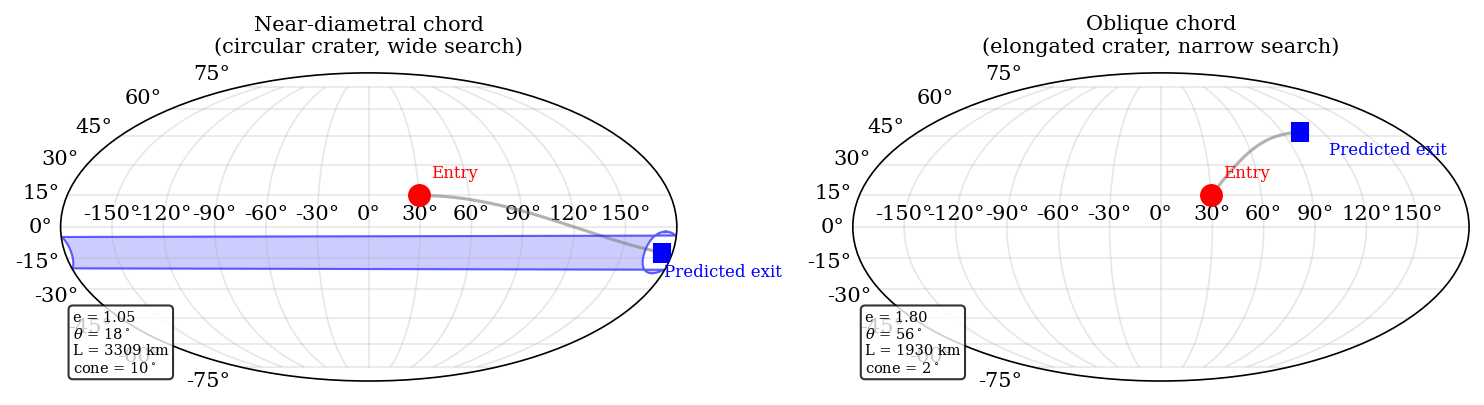

In [11]:
# Figure: Transit Cone Diagram
fig_cone = plot_transit_cone_diagram(
    entry_lon=30.0, entry_lat=15.0,
    ellipticity=1.8, orientation_deg=45.0,
    cone_half_deg=2.0,
)
save_figure(fig_cone, "transit_cone_diagram")
plt.show()

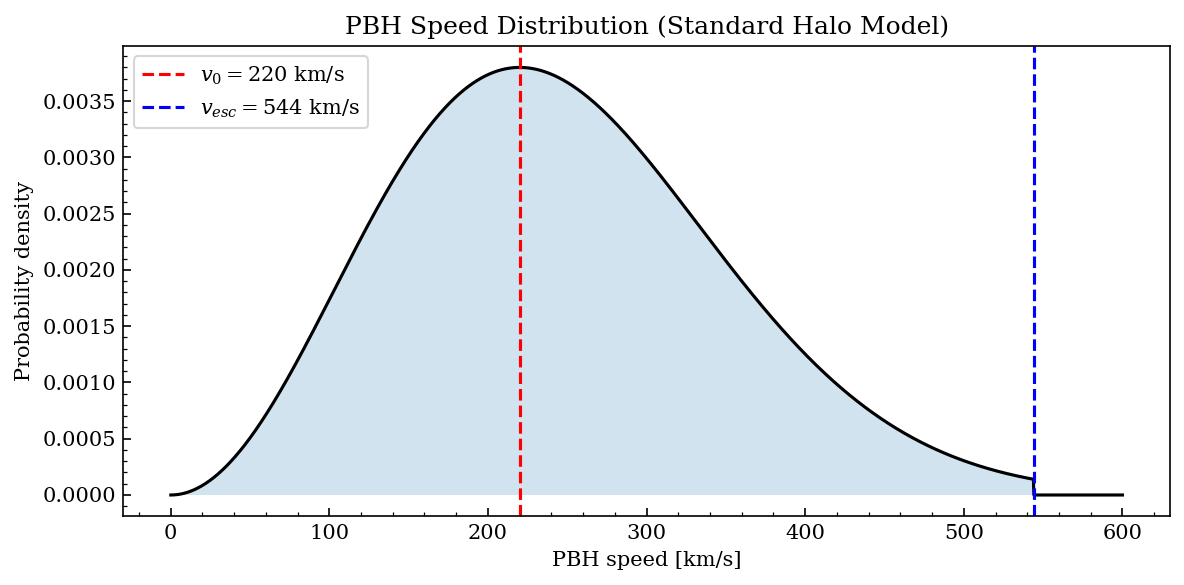

In [12]:
# Figure: PBH Velocity Distribution
fig_vel, ax = plt.subplots(figsize=(8, 4))
v = np.linspace(0.1, 600, 2000)
pdf = maxwell_boltzmann_speed_pdf(v)
ax.plot(v, pdf, 'k-', lw=1.5)
ax.fill_between(v, pdf, alpha=0.2)
ax.axvline(220, color='red', ls='--', label=r'$v_0 = 220$ km/s')
ax.axvline(544, color='blue', ls='--', label=r'$v_{esc} = 544$ km/s')
ax.set_xlabel('PBH speed [km/s]')
ax.set_ylabel('Probability density')
ax.set_title('PBH Speed Distribution (Standard Halo Model)')
ax.legend()
fig_vel.tight_layout()
save_figure(fig_vel, "velocity_distribution")
plt.show()

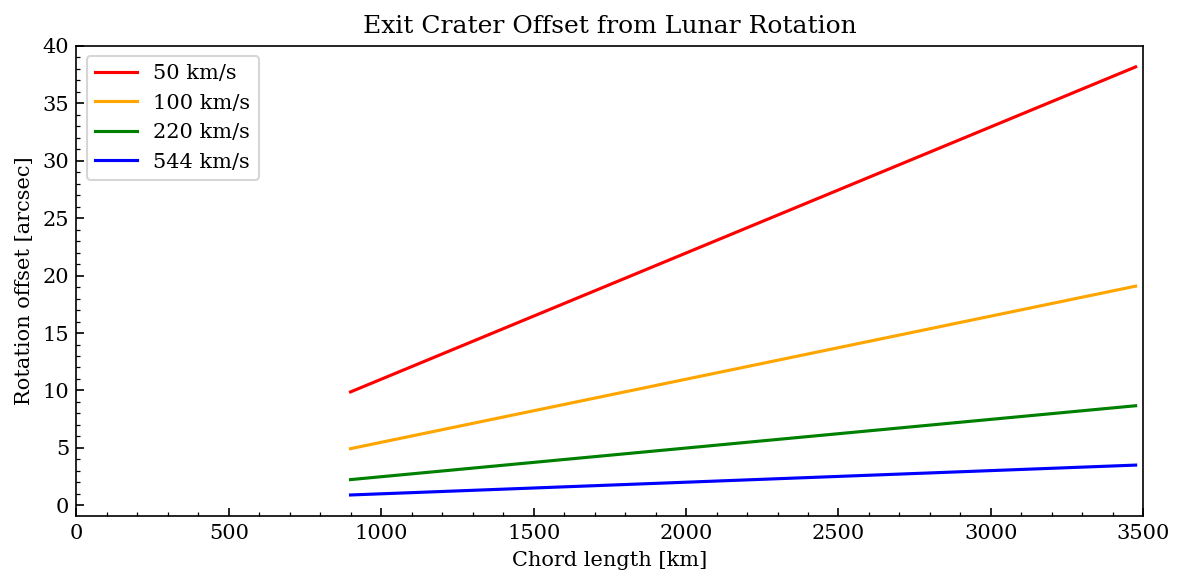

In [13]:
# Figure: Rotation offset vs chord length
fig_rot, ax = plt.subplots(figsize=(8, 4))
seps = np.linspace(30, 180, 200)
L_km = chord_length_from_separation(seps) / 1e3
for v_km_s, color, label in [(50, 'red', '50 km/s'), (100, 'orange', '100 km/s'),
                              (220, 'green', '220 km/s'), (544, 'blue', '544 km/s')]:
    offset = rotation_offset_deg(chord_length_from_separation(seps), v_km_s)
    ax.plot(L_km, offset * 3600, color=color, label=label)  # convert to arcsec

ax.set_xlabel('Chord length [km]')
ax.set_ylabel('Rotation offset [arcsec]')
ax.set_title('Exit Crater Offset from Lunar Rotation')
ax.legend()
ax.set_xlim(0, 3500)
fig_rot.tight_layout()
save_figure(fig_rot, "rotation_offset_vs_chord")
plt.show()

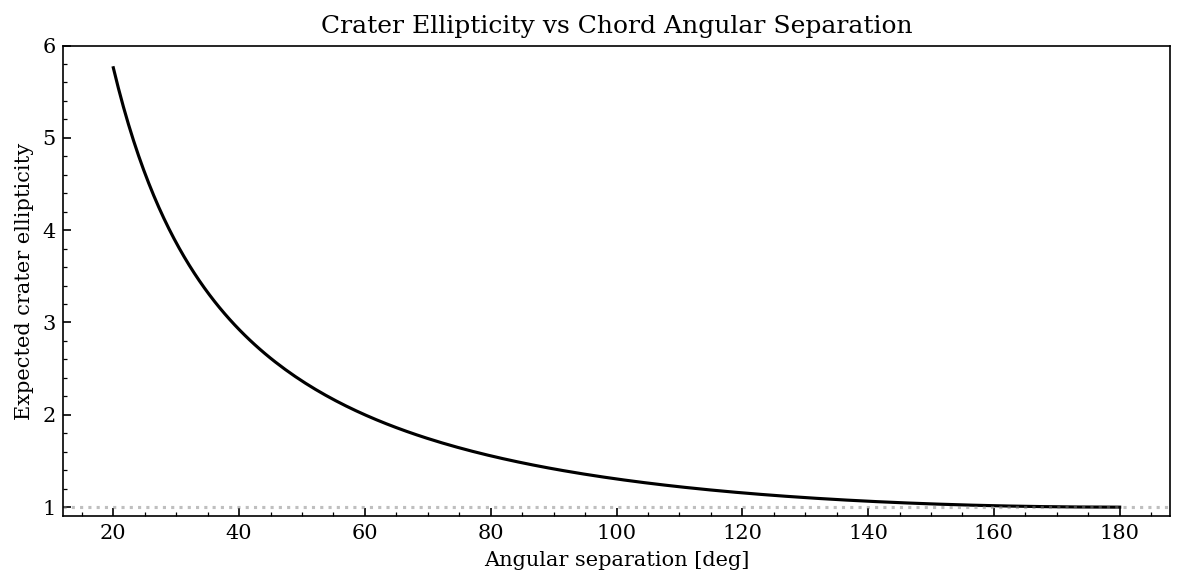

In [14]:
# Figure: Expected ellipticity vs angular separation
fig_ellip, ax = plt.subplots(figsize=(8, 4))
seps = np.linspace(20, 180, 200)
e = expected_ellipticity_from_separation(seps)
ax.plot(seps, e, 'k-', lw=1.5)
ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Angular separation [deg]')
ax.set_ylabel('Expected crater ellipticity')
ax.set_title('Crater Ellipticity vs Chord Angular Separation')
ax.set_ylim(0.9, 6)
fig_ellip.tight_layout()
save_figure(fig_ellip, "ellipticity_vs_separation")
plt.show()

In [ ]:
# Figure: Chord search-space diagram
# Shows which part of the Moon is reachable as an exit crater for a
# given entry crater — the "forbidden zone" (min sep cut) vs the allowed
# region, and the tiny search cones around the two shape-predicted exits.
#
# If real craters are available, we pick a well-detected elliptical example.
# Otherwise we fall back to default illustrative values.

cfg = ChordConfig()

if HAS_CHIPS and not craters.empty and "shape_reliable" in craters.columns:
    reliable = craters[craters["shape_reliable"] & (craters["ellipticity"] > 1.2)]
    if not reliable.empty:
        # Pick a crater near the middle of the ellipticity distribution
        ex = reliable.sort_values("ellipticity").iloc[len(reliable) // 2]
        _lon  = float(ex["lon_deg"])
        _lat  = float(ex["lat_deg"])
        _ori  = float(ex.get("orientation_deg", 45.0))
        _e    = float(ex["ellipticity"])
    else:
        _lon, _lat, _ori, _e = 30.0, 15.0, 45.0, 1.5
else:
    _lon, _lat, _ori, _e = 30.0, 15.0, 45.0, 1.5

fig_space = plot_chord_space_diagram(
    config=cfg,
    entry_lon_deg=_lon,
    entry_lat_deg=_lat,
    orientation_deg=_ori,
    ellipticity=_e,
)
save_figure(fig_space, "chord_space_diagram")
plt.show()

## 3. Detection Statistics

Total craters: 435,705

Radius statistics [m]:
count    435705.000000
mean          5.613944
std           1.783384
min           4.181779
25%           4.181779
50%           5.200210
75%           6.466668
max          10.000000
Name: radius_m, dtype: float64

Freshness Index statistics:
count    435705.000000
mean          0.192925
std           0.104087
min           0.008493
25%           0.117067
50%           0.172341
75%           0.246110
max           0.994723
Name: freshness_index, dtype: float64

  Pairing threshold (min_freshness = 0.15):
    Craters passing: 260,266 / 435,705 (59.73%)

Depth proxy statistics:
count    435705.000000
mean          0.302194
std           0.251561
min           0.000000
25%           0.097823
50%           0.238687
75%           0.448116
max           0.999998
Name: depth_proxy, dtype: float64


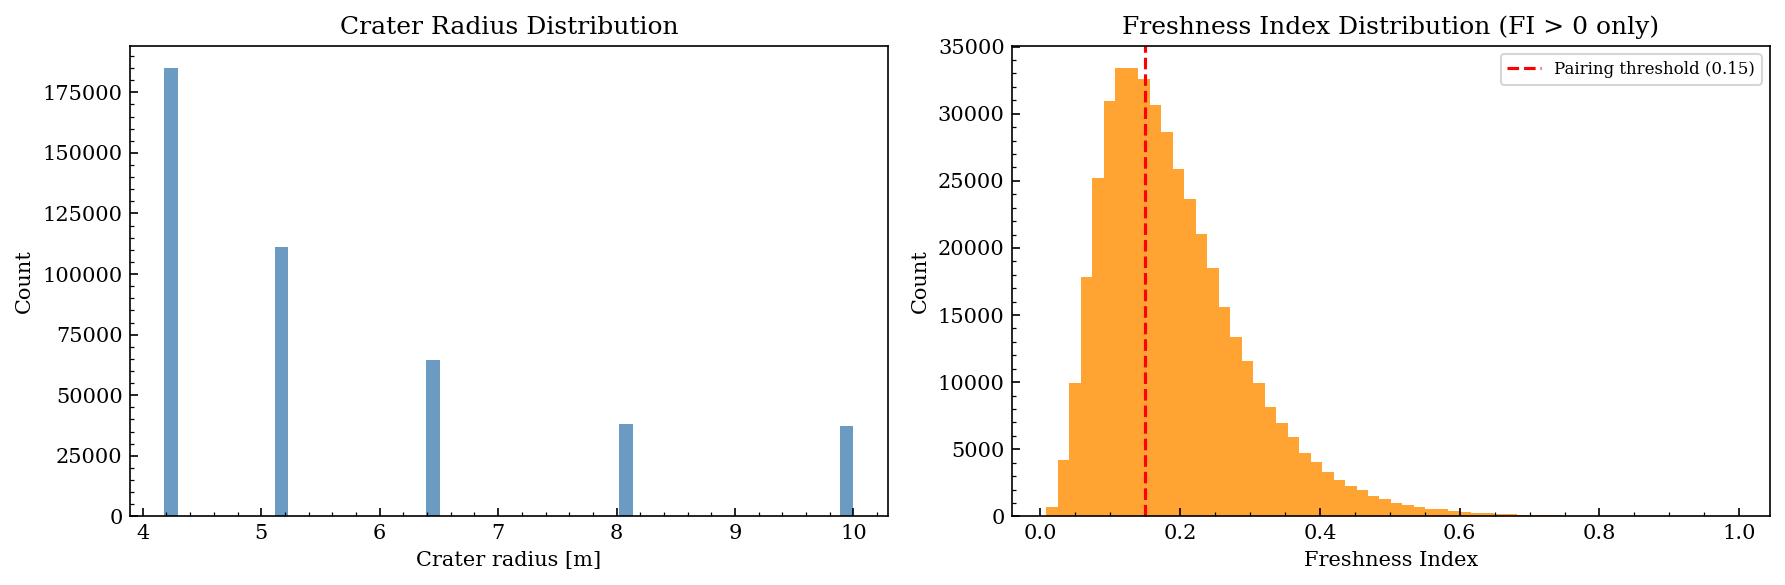

In [15]:
if HAS_CHIPS:
    cfg = ChordConfig()
    print(f"Total craters: {len(craters):,}")

    print(f"\nRadius statistics [m]:")
    print(craters['radius_m'].describe())

    print(f"\nFreshness Index statistics:")
    if 'freshness_index' in craters.columns:
        print(craters['freshness_index'].describe())

        # Pairing threshold analysis
        min_fi = cfg.min_freshness
        n_above = (craters['freshness_index'] >= min_fi).sum()
        pct = 100.0 * n_above / len(craters) if len(craters) > 0 else 0
        print(f"\n  Pairing threshold (min_freshness = {min_fi}):")
        print(f"    Craters passing: {n_above:,} / {len(craters):,} ({pct:.2f}%)")
        if n_above == 0:
            print("    NOTE: No craters pass the freshness threshold —")
            print("    this means no pairs will be formed. This is expected for")
            print("    small test runs where most chips are in old terrain.")
        elif n_above < 10:
            print(f"    WARNING: Only {n_above} craters pass — very few pairs possible.")

    print(f"\nDepth proxy statistics:")
    if 'depth_proxy' in craters.columns:
        print(craters['depth_proxy'].describe())

    # Radius distribution
    fig_rad, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(craters['radius_m'], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[0].set_xlabel('Crater radius [m]')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Crater Radius Distribution')

    if 'freshness_index' in craters.columns:
        fi = craters['freshness_index']
        fi_nonzero = fi[fi > 0]
        if len(fi_nonzero) > 0:
            axes[1].hist(fi_nonzero, bins=60, color='darkorange', edgecolor='none', alpha=0.8)
            axes[1].axvline(cfg.min_freshness, color='red', ls='--',
                            label=f'Pairing threshold ({cfg.min_freshness})')
            axes[1].legend(fontsize=8)
        else:
            axes[1].text(0.5, 0.5, 'All FI = 0', ha='center', va='center',
                         transform=axes[1].transAxes, fontsize=14, color='gray')
        axes[1].set_xlabel('Freshness Index')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Freshness Index Distribution (FI > 0 only)')

    fig_rad.tight_layout()
    save_figure(fig_rad, "detection_statistics")
    plt.show()
else:
    print("No chip results. Skipping detection statistics.")

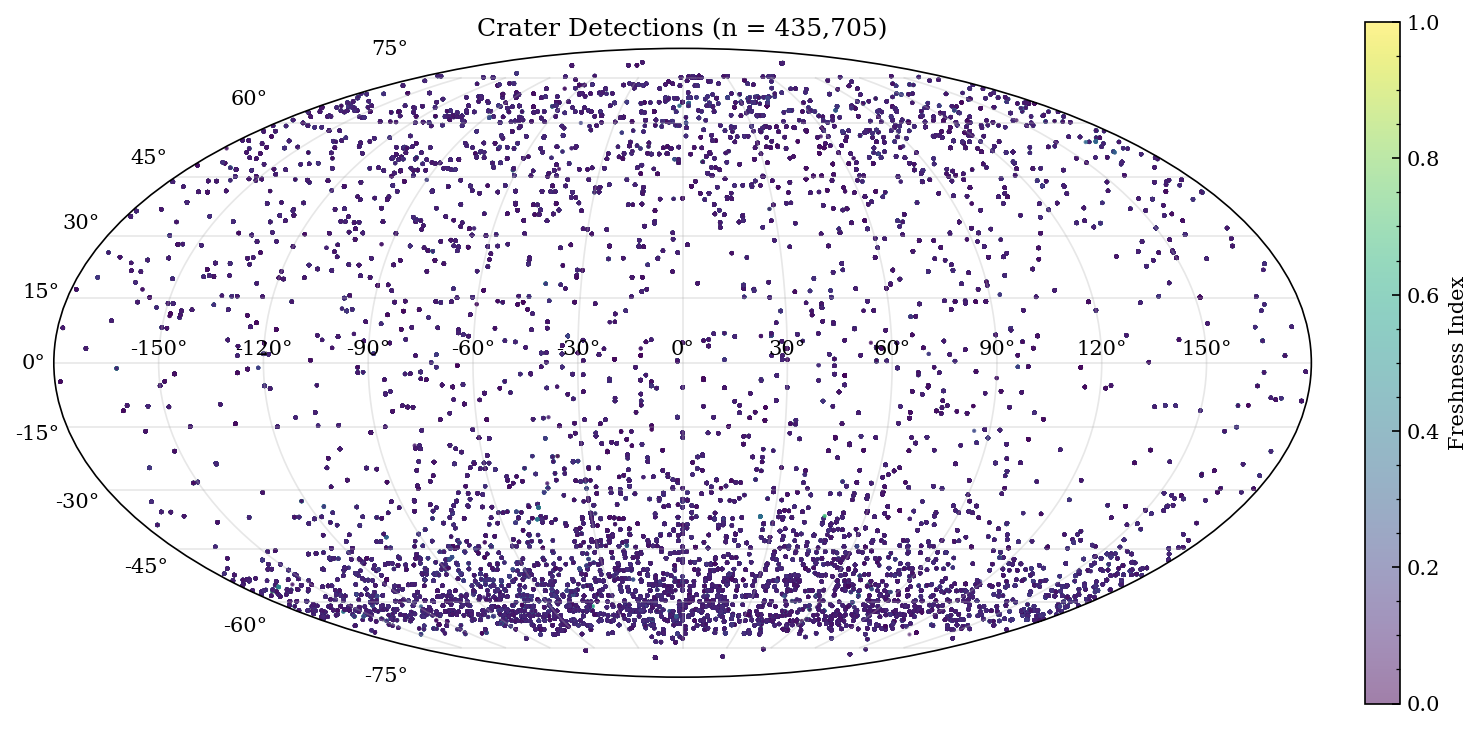

In [16]:
if HAS_CHIPS and 'freshness_index' in craters.columns:
    fig_cov = plot_spatial_coverage(craters)
    save_figure(fig_cov, "spatial_coverage")
    plt.show()
else:
    print("No chip data for spatial coverage plot.")

## 4. Pair Analysis

Total scored pairs: 50
Significant pairs (BH-FDR): 0
  No statistically significant detections after BH-FDR correction.
  Proceeding with full analysis on top-scoring pairs.

Best pair:
  Score:      1.000000
  Separation: 179.9457 deg
  p-value:    0.265367


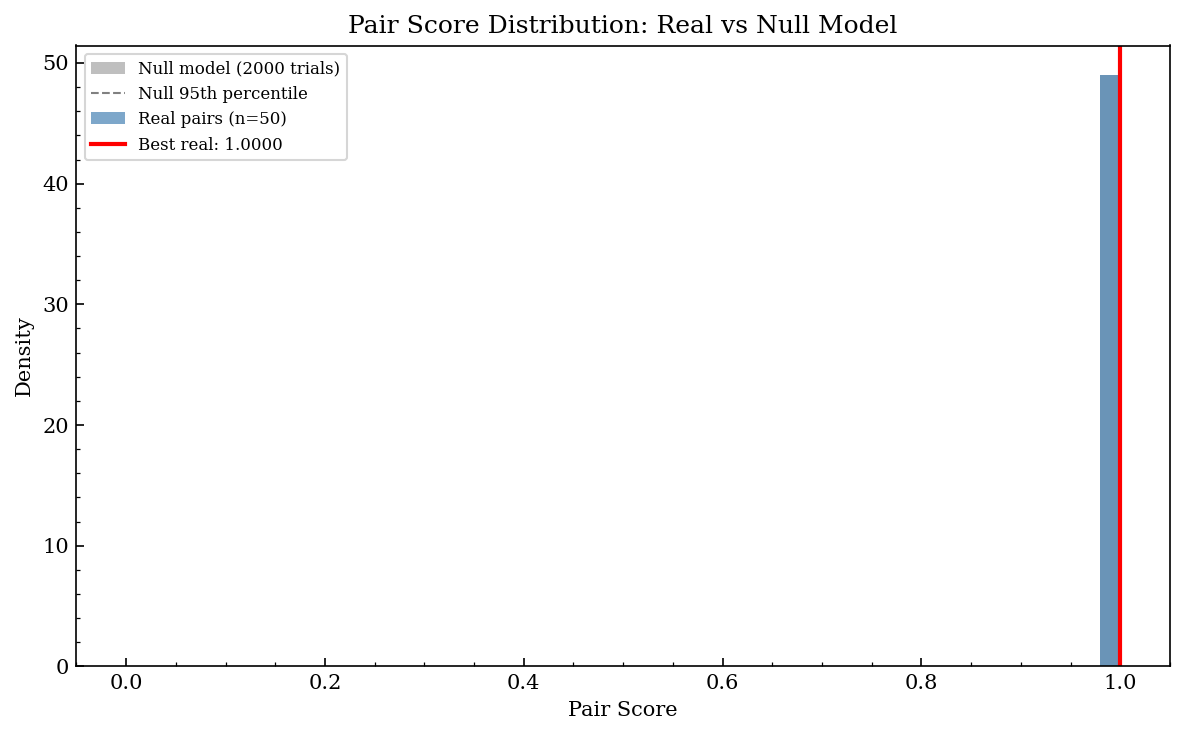

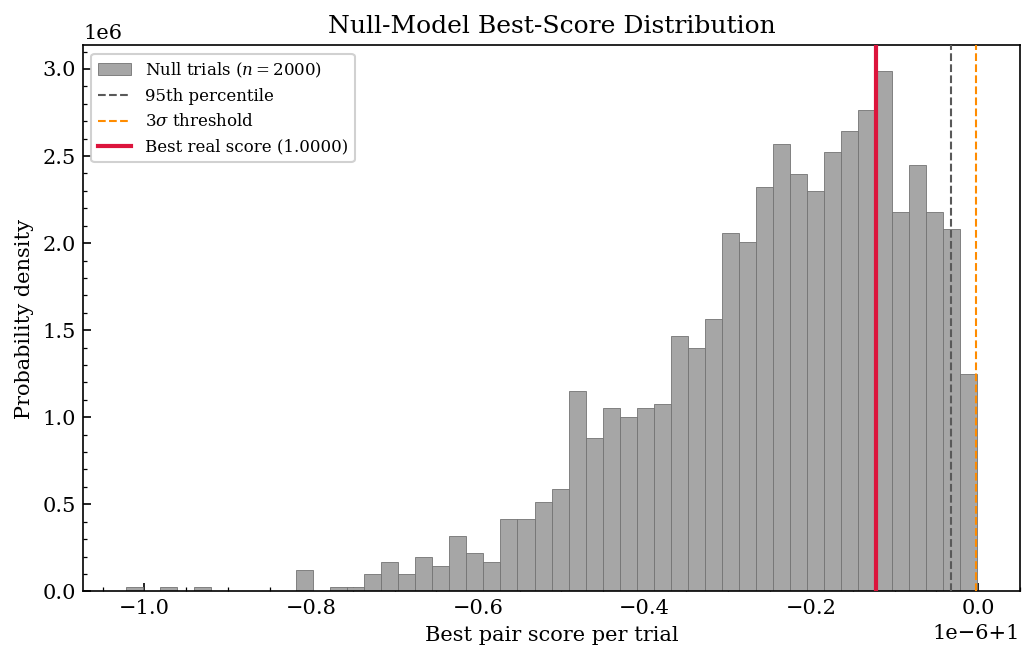

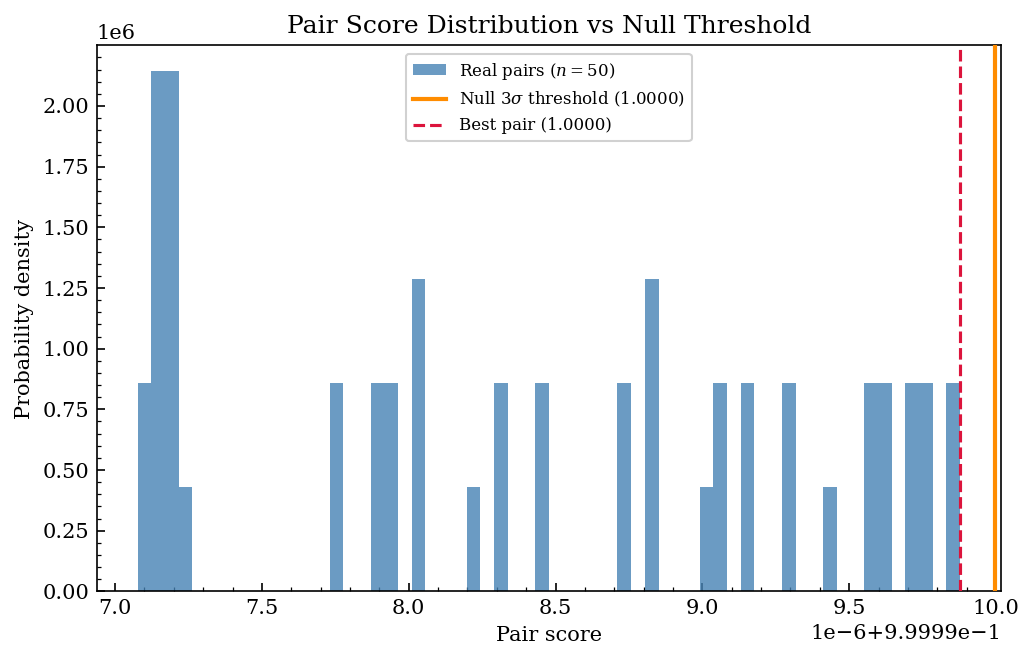

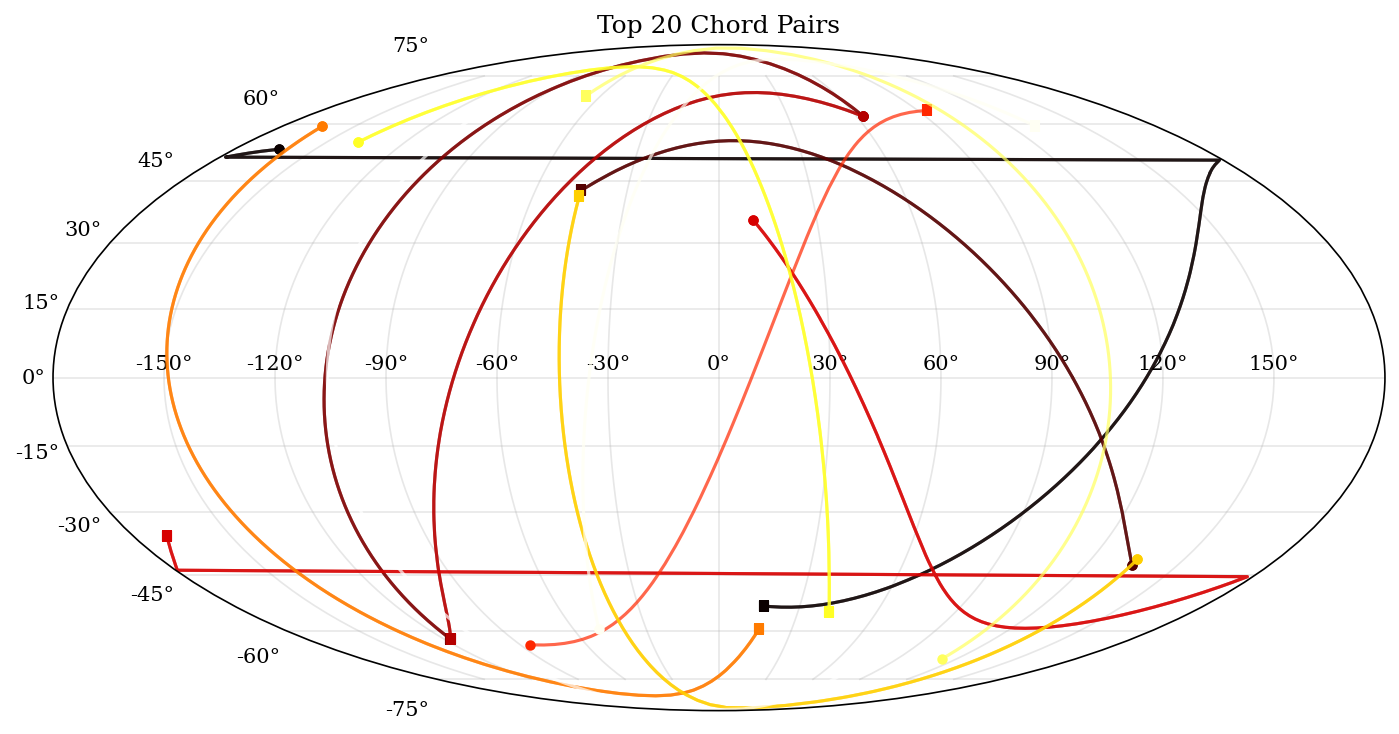

/home/diogocapelo/.venv/jupyter/lib/python3.12/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/diogocapelo/.venv/jupyter/lib/python3.12/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


ValueError: need at least one array to concatenate

Error in callback <function _draw_all_if_interactive at 0x79e403a76c00> (for post_execute), with arguments args (),kwargs {}:


ValueError: need at least one array to concatenate

ValueError: need at least one array to concatenate

<Figure size 1800x900 with 2 Axes>

In [17]:
if HAS_RESULTS and len(all_pairs) > 0:
    print(f"Total scored pairs: {len(all_pairs):,}")
    n_sig = len(sig_pairs)
    print(f"Significant pairs (BH-FDR): {n_sig}")
    if n_sig == 0:
        print("  No statistically significant detections after BH-FDR correction.")
        print("  Proceeding with full analysis on top-scoring pairs.\n")

    # --- Top pairs summary ---
    cfg = ChordConfig()
    top_k = min(cfg.top_pairs_to_report, len(all_pairs))
    top_pairs = all_pairs.head(top_k)
    best = all_pairs.iloc[0]
    print(f"Best pair:")
    print(f"  Score:      {best['score']:.6f}")
    print(f"  Separation: {best['separation_deg']:.4f} deg")
    if 'p_value' in all_pairs.columns:
        print(f"  p-value:    {best['p_value']:.6f}")

    # --- Figure: Score distribution (real vs null) ---
    if null_scores.size > 0:
        fig_scores = plot_score_distribution(
            all_pairs["score"].to_numpy(), null_scores,
        )
        save_figure(fig_scores, "score_distribution")
        plt.show()

    # --- Figure: Null-model best-score distribution ---
    if null_scores.size > 0:
        fig_null = plot_null_distribution(
            null_scores,
            best_real_score=float(best["score"]),
        )
        save_figure(fig_null, "null_best_score_distribution")
        plt.show()

    # --- Figure: Pair score histogram with 3-sigma null threshold ---
    if null_scores.size > 0:
        fig_thresh = plot_pair_scores_with_threshold(
            all_pairs["score"].to_numpy(), null_scores,
        )
        save_figure(fig_thresh, "pair_scores_vs_null_threshold")
        plt.show()

    # --- Figure: Chord map of top pairs ---
    fig_map = plot_chord_map(all_pairs, n_best=20)
    save_figure(fig_map, "chord_map_top20")
    plt.show()

    # --- Figure: Crater heatmap with top-pair locations ---
    fig_heatmap = plot_crater_map_with_pairs(
        craters, all_pairs, n_best=min(20, len(all_pairs)),
    )
    save_figure(fig_heatmap, "crater_map_with_top_pairs")
    plt.show()
else:
    print("No pair results to analyse.")

## 5. Sensitivity Analysis

Score component breakdown for top 10 pairs:

 score  separation_deg  radius_a_m  radius_b_m  T_diametrality  T_radius  T_freshness  T_ellipticity  T_orientation  T_velocity
   1.0      179.945714    4.181779    4.181779             1.0       1.0          1.0            1.0            1.0         1.0
   1.0      179.945714    4.181779    4.181779             1.0       1.0          1.0            1.0            1.0         1.0
   1.0      179.956994    5.200210    5.200210             1.0       1.0          1.0            1.0            1.0         1.0
   1.0      179.956994    5.200210    5.200210             1.0       1.0          1.0            1.0            1.0         1.0
   1.0      179.912770    4.181779    4.181779             1.0       1.0          1.0            1.0            1.0         1.0
   1.0      179.912770    4.181779    4.181779             1.0       1.0          1.0            1.0            1.0         1.0
   1.0      179.948982    5.200210    5.200210             

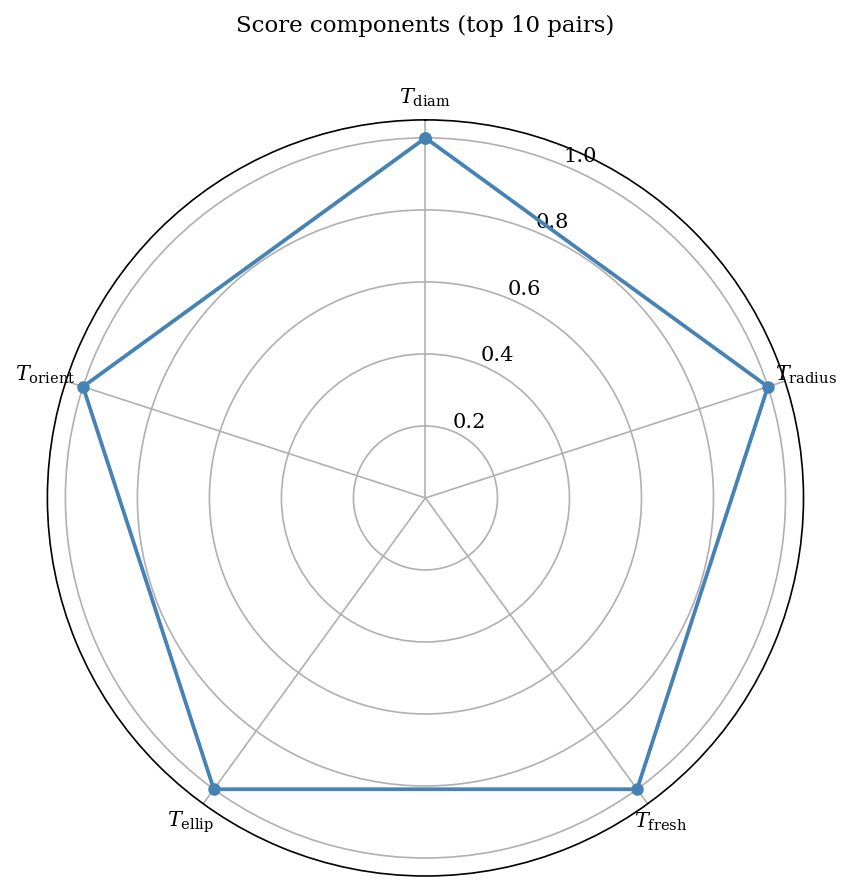

In [18]:
if HAS_RESULTS and len(all_pairs) > 0:
    score_cols = [c for c in all_pairs.columns if c.startswith("T_")]
    display_cols = ["score", "separation_deg", "radius_a_m", "radius_b_m"] + score_cols
    avail_display = [c for c in display_cols if c in all_pairs.columns]

    n_show = min(10, len(all_pairs))
    print(f"Score component breakdown for top {n_show} pairs:\n")
    print(all_pairs[avail_display].head(n_show).to_string(index=False))

    if 'p_value' in all_pairs.columns:
        print(f"\np-values for top {n_show} pairs:")
        pv_cols = ["score", "p_value"]
        if "bh_significant" in all_pairs.columns:
            pv_cols.append("bh_significant")
        print(all_pairs[pv_cols].head(n_show).to_string(index=False))

    # --- Figure: Score component radar (star) plot ---
    fig_star = plot_score_component_star(all_pairs, n_top=n_show)
    save_figure(fig_star, "score_component_star")
    plt.show()
else:
    print("No results for sensitivity analysis.")

## 5b. Rescoring with Alternative Configurations

Rescore real pairs and null-model best pairs with a custom `ChordConfig`.
This allows rapid iteration on scoring parameters without rerunning the
Monte Carlo or the pairing stage.

In [22]:
import json
from moonpiercer.pairing import rescore_pairs

# ── Tweak these to experiment ──────────────────────────────────────
custom_cfg = ChordConfig(
    sigma_freshness=0.01,        # tighter freshness penalty
    sigma_radius=5.0,            # wider (de-emphasise poorly-resolved radius)
    sigma_ellipticity=0.04,      # tighter ellipticity penalty
    sigma_orientation_deg=3.0,   # tighter orientation penalty
    diametrality_exponent=4.0,   # quadratic preference for diametral chords
)

# ── Rescore real pairs ─────────────────────────────────────────────
if HAS_RESULTS and len(all_pairs) > 0:
    rescored = rescore_pairs(all_pairs, config=custom_cfg)
    print(f"Rescored {len(rescored):,} real pairs.")
    print(f"  Score range: {rescored['score'].min():.6f} – {rescored['score'].max():.6f}")
    print(f"  Score std:   {rescored['score'].std():.6f}")

    n_show = min(50, len(rescored))
    t_cols = [c for c in rescored.columns if c.startswith("T_")]
    print(f"\nTop {n_show} rescored pairs:")
    print(rescored[["score", "separation_deg", "radius_a_m", "radius_b_m"] + t_cols].head(n_show).to_string(index=False))
else:
    rescored = pd.DataFrame()
    print("No real pairs to rescore.")

# ── Rescore null-model best pairs (if details were saved) ─────────
null_details_path = RUN_DIR / "null_pair_details.json"
rescored_null_scores = np.array([])

if null_details_path.exists():
    with open(null_details_path) as f:
        null_details = json.load(f)
    print(f"\nLoaded {len(null_details):,} null pair details from {null_details_path.name}")

    rescored_null_scores = np.zeros(len(null_details), dtype=np.float64)
    for i, det in enumerate(null_details):
        if not det:  # empty dict = no pairs in that trial
            continue
        # Build a single-row DataFrame and rescore
        row_df = pd.DataFrame([det])
        row_rescored = rescore_pairs(row_df, config=custom_cfg)
        rescored_null_scores[i] = float(row_rescored["score"].iloc[0])

    print(f"  Null score range: {rescored_null_scores.min():.6f} – {rescored_null_scores.max():.6f}")
    print(f"  Null score mean:  {rescored_null_scores.mean():.6f}")
    print(f"  Null score 95th:  {np.quantile(rescored_null_scores, 0.95):.6f}")
    print(f"  Null score 99th:  {np.quantile(rescored_null_scores, 0.99):.6f}")

    # ── Recompute significance with rescored values ────────────────
    if len(rescored) > 0:
        from moonpiercer.null_model import compute_significance
        rescored_sig = compute_significance(rescored, rescored_null_scores, alpha=custom_cfg.fdr_alpha)
        n_sig_new = rescored_sig["bh_significant"].sum()
        print(f"\n  Rescored significant pairs (BH-FDR α={custom_cfg.fdr_alpha}): {n_sig_new}")
        print(f"  Best rescored p-value: {rescored_sig['p_value'].min():.6f}")
else:
    print("\nNo null_pair_details.json found — null rescoring requires a rerun with save_pair_details=True.")

Rescored 50 real pairs.
  Score range: 0.999681 – 0.999998
  Score std:   0.000103

Top 50 rescored pairs:
   score  separation_deg  radius_a_m  radius_b_m  T_diametrality  T_radius  T_freshness  T_ellipticity  T_orientation  T_velocity  T_position
0.999998      179.945714    4.181779    4.181779        1.000000       1.0     0.999999            1.0            1.0         1.0         1.0
0.999998      179.945714    4.181779    4.181779        1.000000       1.0     0.999999            1.0            1.0         1.0         1.0
0.999996      179.912770    4.181779    4.181779        0.999999       1.0     0.999998            1.0            1.0         1.0         1.0
0.999996      179.912770    4.181779    4.181779        0.999999       1.0     0.999998            1.0            1.0         1.0         1.0
0.999994      179.895448    4.181779    4.181779        0.999998       1.0     0.999996            1.0            1.0         1.0         1.0
0.999994      179.895448    4.181779    4

## 6. Crater Survival Timescale

Compute the survival timescale $\tau_{\rm surv}$ using topographic diffusion.

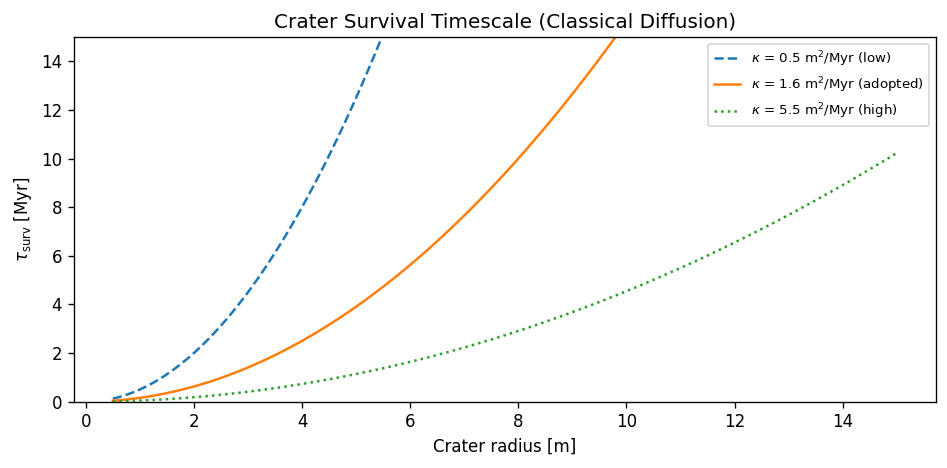


Survival times at kappa = 1.6 m^2/Myr:
  r = 1 m: tau = 0.16 Myr
  r = 2 m: tau = 0.62 Myr
  r = 3 m: tau = 1.41 Myr
  r = 5 m: tau = 3.91 Myr
  r = 10 m: tau = 15.62 Myr


In [ ]:
from moonpiercer.constants import (
    KAPPA_CLASSICAL_LOW_M2_PER_MYR,
    KAPPA_CLASSICAL_HIGH_M2_PER_MYR,
    KAPPA_ADOPTED_M2_PER_MYR,
)

# Classical diffusion: tau = r^2 / (4 * kappa)
radii_m = np.array([1, 2, 3, 5, 10])  # crater radii in metres
kappa = KAPPA_ADOPTED_M2_PER_MYR

fig_tau, ax = plt.subplots(figsize=(8, 4))
for kap, label, ls in [
    (KAPPA_CLASSICAL_LOW_M2_PER_MYR, r'$\kappa$ = 0.5 m$^2$/Myr (low)', '--'),
    (KAPPA_ADOPTED_M2_PER_MYR, r'$\kappa$ = 1.6 m$^2$/Myr (adopted)', '-'),
    (KAPPA_CLASSICAL_HIGH_M2_PER_MYR, r'$\kappa$ = 5.5 m$^2$/Myr (high)', ':'),
]:
    r_range = np.linspace(0.5, 15, 200)
    tau = r_range**2 / (4 * kap)
    ax.plot(r_range, tau, ls=ls, lw=1.5, label=label)

ax.set_xlabel('Crater radius [m]')
ax.set_ylabel(r'$\tau_{\rm surv}$ [Myr]')
ax.set_title('Crater Survival Timescale (Classical Diffusion)')
ax.legend(fontsize=8)
ax.set_ylim(0, 15)
fig_tau.tight_layout()
save_figure(fig_tau, "crater_survival_timescale")
plt.show()

print(f"\nSurvival times at kappa = {kappa} m^2/Myr:")
for r in radii_m:
    tau = r**2 / (4 * kappa)
    print(f"  r = {r} m: tau = {tau:.2f} Myr")

## 7. Key Physical Parameters Summary

In [ ]:
max_offset = max_physical_angular_offset_deg(v_min_km_s=50.0)
max_offset_m = max_offset * np.pi / 180.0 * LUNAR_RADIUS_M

print("Physical constraints summary:")
print(f"  Max rotation offset (50 km/s, diametral): {max_offset:.5f} deg ({max_offset * 3600:.1f} arcsec, {max_offset_m:.0f} m)")
print(f"  Max rotation offset (220 km/s, diametral): {float(rotation_offset_deg(2*LUNAR_RADIUS_M, 220)):.5f} deg")
print(f"  Adopted hard cut: {ChordConfig().max_chord_deviation_deg} deg")
print(f"  Safety margin: {ChordConfig().max_chord_deviation_deg / max_offset:.1f}x physical max")
print(f"  Lunar surface area: {LUNAR_SURFACE_AREA_KM2:.0f} km^2")
print(f"  Lunar radius: {LUNAR_RADIUS_M:.0f} m")
print(f"  Lunar diameter: {2*LUNAR_RADIUS_M/1e3:.1f} km")

Physical constraints summary:
  Max rotation offset (50 km/s, diametral): 0.01060 deg (38.2 arcsec, 321 m)
  Max rotation offset (220 km/s, diametral): 0.00241 deg
  Adopted hard cut: 0.05 deg
  Safety margin: 4.7x physical max
  Lunar surface area: 37932328 km^2
  Lunar radius: 1737400 m
  Lunar diameter: 3474.8 km
